<h3><span style="text-decoration: underline;"><strong>Title: Air Quality Forecasting using Time Series Machine Learning Models</strong></span></h3>
<h4><strong>Objective</strong></h4>
The objective of this project assignment is to develop a machine learning model that predicts future air quality levels based on historical air quality data and relevant environmental factors. Students will gain practical experience in time series analysis, feature engineering, model selection, and evaluation for air quality forecasting.

A few years ago, China established the Air Quality Index (AQI) based on the level of five pollutants atmospheres, namely sulfur dioxide (SO2), nitrogen dioxide (NO2), particulate matter (PM10), carbon monoxide (CO) and ozone (O3) measured at the monitoring stations in each city.

The dataset consists of hourly atmospheric measurements from 12 cities in Beijing, covering the period from March 1st, 2013, to February 28th, 2017. The target variables are PM2.5, PM10, SO2, NO2, CO, and O3, along with independent variables like temperature, pressure, dew point temperature, rainfall, wind speed, and wind direction.
<h4><strong>Requirements</strong></h4>
<ol>
 	<li><a href="https://www.openml.org/search?type=data&amp;status=active&amp;id=42933">Dataset</a>: You can use the one provided or let your instructor know the alternative you prefer.</li>
 	<li>Data Preprocessing:
<ul>
 	<li>Students should handle any missing values, outliers, or erroneous readings in the dataset to ensure data quality.</li>
 	<li>Students should consider temporal resolutions (hourly, daily) and choose an appropriate aggregation level for the analysis.</li>
 	<li>Students should split the dataset into training and testing sets, ensuring a sufficient time duration for each set.</li>
</ul>
</li>
 	<li>Feature Engineering:
<ul>
 	<li>Students should engineer relevant features from the historical air quality data. Examples include lagged variables, moving averages, time-based indicators, and meteorological data like temperature, humidity, wind speed, or atmospheric pressure.</li>
 	<li>Students should consider the influence of external factors, such as industrial activities, geographical attributes, or seasonal variations, on air quality.</li>
</ul>
</li>
 	<li>Model Selection and Training:
<ul>
 	<li>Students should explore and experiment with various time series machine learning models suitable for air quality forecasting, such as ARIMA, SARIMA, Prophet, or LSTM.</li>
 	<li>Students should train multiple models using the training dataset and tune the model hyperparameters, if applicable.</li>
 	<li>Students should compare the performance of different models using appropriate evaluation metrics, such as RMSE, MAE, or accuracy measures specific to air quality indices.</li>
</ul>
</li>
 	<li>Model Evaluation and Visualization:
<ul>
 	<li>Students should evaluate the performance of the selected model(s) on the testing dataset.</li>
 	<li>Students should visualize the predicted air quality levels alongside the actual values to assess the accuracy and reliability of their model.</li>
 	<li>Students should analyze and interpret the model's performance, discussing its ability to capture pollution patterns, handle seasonality, and make accurate forecasts.</li>
</ul>
</li>
</ol>
<h4>Bonus Challenge</h4>
<ul>
 	<li style="list-style-type: none;">
<ul>
 	<li style="list-style-type: none;">
<ul>
 	<li>Students can explore advanced topics, such as ensemble methods, hybrid models, or spatial-temporal modeling techniques to incorporate spatial correlations and neighboring air quality stations.</li>
 	<li>Students can investigate the impact of additional data sources, such as satellite imagery, land use information, or real-time sensor data, on air quality forecasting.</li>
 	<li>Students can develop visualizations or interactive dashboards to communicate the forecasted air quality information effectively.</li>
</ul>
</li>
</ul>
</li>
</ul>
Remember to document your process, explain your decisions, and present your results effectively. Good luck with your project!
<div class="markdown-heading" dir="auto">
<h4 class="heading-element" dir="auto"><span style="text-decoration: underline;">Important Notes</span></h4>
<a id="user-content-important-notes" class="anchor" href="https://github.com/Afkerian/Beijing-Multi-Site-Air-Quality-Data-Data-Set#important-notes" aria-label="Permalink: Important notes"></a></div>
<ul dir="auto">
 	<li>Any data pre-processing steps must be presented and justified.</li>
 	<li>All algorithms and parameters used must be indicated.</li>
 	<li>The organization of the text and presentation, clarity of language and ideas are rewarded.</li>
 	<li>Long sequences of poorly formatted results are penalized.</li>
 	<li>The report should also make reference to any source used and make explicit which part of the work was influenced by her.</li>
 	<li>It is important that your code does not depend on an absolute path, so that it can be executed anywhere. computer. This project should be posted in your GitHub repo with the data. You can split your notebooks into 2 or 3 for better readability.</li>
 	<li>If the notebook contains code that takes a long time to run, it should be included with the option eval=FALSE so that the code is not executed. If the output of your code is needed, you can execute it locally on your computer, save it to a binary file, and load it into your report.</li>
</ul>
&nbsp;
<h3><span style="text-decoration: underline;"><strong>Your Feedback Matters!</strong></span></h3>
At Zindua School, we are committed to continuously improving your learning experience. Each week, we provide a short feedback form to understand what’s working well and where we can improve.

By sharing your thoughts, you help us refine our content, enhance support, and ensure a better learning experience for both you and future students. The form takes just a minute to complete, and your insights are invaluable in shaping the program.

???? <strong>Please take a moment to fill out this week's feedback form here:</strong> <a href="https://base.zinduaschool.com/form/Djt-J9trbBxjODiX5VQQ6y7wvTD5Xy7GcYsgGwPSkOI">Weekly Feedback Form</a>

# Beijing Air Quality Forecasting with Time-Series Machine Learning

**Objective:** forecast next-hour PM2.5 concentration (µg/m³) at Beijing monitoring stations from earlier pollutant, weather, wind, station, and calendar information. This notebook uses the hourly Beijing Multi-Site Air Quality dataset (12 stations; March 2013–February 2017).

The notebook follows the assignment stages: data quality, exploratory analysis, forecasting features, chronological model comparison, test visualization, and interpretation. The test period is later than every training observation.


## 1. Problem and forecast design

For each station and timestamp *t*, the target is PM2.5 at *t+1 hour*. Predictors include readings available at *t*, such as PM10 and weather, as well as lagged PM2.5. That is a practical one-hour-ahead forecast: no value measured at the forecast hour is used as an input. We train on the first 80% of calendar time and test on the final 20%, retaining all stations in both periods.

The dataset is an alternative supplied by the assignment (OpenML dataset 42933). The task focuses on PM2.5, one of the six pollutant targets named in the instructions. MAE and RMSE are reported in µg/m³; RMSE is the primary selection metric because it penalizes large misses more strongly.


## 2. Load data and inspect quality

The data file is stored beside this notebook in `data/`. The path is relative, so the project can be moved as a folder. The OpenML parquet file preserves the dataset compactly; pandas needs `pyarrow` to read it.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
DATA_PATH = Path('data') / 'beijing_air_quality.parquet'
raw = pd.read_parquet(DATA_PATH)
print('Shape:', raw.shape)
print('Date range:', pd.to_datetime(raw[['year','month','day','hour']]).min(), 'to', pd.to_datetime(raw[['year','month','day','hour']]).max())
print('Stations:', raw['station'].nunique())
raw.head()


Shape: (420768, 18)
Date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Stations: 12


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [2]:
raw.info()
print('Missing values:')
print(raw.isna().sum().sort_values(ascending=False))
print('Exact duplicate rows:', raw.duplicated().sum())
print('Station counts:')
print(raw['station'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  uint8  
 3   day      420768 non-null  uint8  
 4   hour     420768 non-null  uint8  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(2), object(2), uint8(3)
memory usage: 49.4+ MB
Missing values:
CO         20701
O3

### Cleaning decisions

`No` is an input row number, not a physical predictor, so it is removed. The year/month/day/hour fields form a proper timestamp. Sensor missing values in Beijing data are represented as missing values (NaN); zero is retained because zero rainfall and occasional zero pollutant readings can be physically valid. We do not delete IQR-flagged pollution peaks automatically: high pollution episodes are important forecast cases, and the IQR rule alone cannot distinguish a real event from a sensor error. Missing PM2.5 target rows are excluded because there is no observed outcome to learn or score. Missing predictor readings are filled with the median learned from training data only, preventing test-period information from shaping preprocessing.


In [3]:
data = raw.drop(columns=['No']).copy()
data['datetime'] = pd.to_datetime(data[['year','month','day','hour']])
data = data.drop(columns=['year','month','day','hour'])
data = data.sort_values(['datetime','station']).drop_duplicates(['datetime','station']).reset_index(drop=True)
print('Rows after removing duplicate station-hours:', len(data))
print('Missing PM2.5 targets:', data['PM2.5'].isna().sum())
print('Zero counts in pollutants / rainfall:')
print((data[['PM2.5','PM10','SO2','NO2','CO','O3','RAIN']] == 0).sum())


Rows after removing duplicate station-hours: 420768
Missing PM2.5 targets: 8739
Zero counts in pollutants / rainfall:


PM2.5         0
PM10          0
SO2           0
NO2           0
CO            0
O3            0
RAIN     403858
dtype: int64


## 3. Exploratory data analysis

The EDA describes coverage, target distributions, station differences, and temporal patterns. These checks help distinguish network-wide behavior from station-specific variation and motivate hour/day/season features.


In [4]:
print(data.groupby('station')['datetime'].agg(['min','max','count']))
print('Pollutant and meteorological summary:')
display(data[['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']].describe().T)


                     min                 max  count
station                                            
Aotizhongxin  2013-03-01 2017-02-28 23:00:00  35064
Changping     2013-03-01 2017-02-28 23:00:00  35064
Dingling      2013-03-01 2017-02-28 23:00:00  35064
Dongsi        2013-03-01 2017-02-28 23:00:00  35064
Guanyuan      2013-03-01 2017-02-28 23:00:00  35064
Gucheng       2013-03-01 2017-02-28 23:00:00  35064
Huairou       2013-03-01 2017-02-28 23:00:00  35064
Nongzhanguan  2013-03-01 2017-02-28 23:00:00  35064
Shunyi        2013-03-01 2017-02-28 23:00:00  35064
Tiantan       2013-03-01 2017-02-28 23:00:00  35064
Wanliu        2013-03-01 2017-02-28 23:00:00  35064
Wanshouxigong 2013-03-01 2017-02-28 23:00:00  35064
Pollutant and meteorological summary:


,count,mean,std,min,25%,50%,75%,max
PM2.5,412029.0,79.793428,80.822391,2.0000,20.0,55.0,111.0,999.0
PM10,414319.0,104.602618,91.772426,2.0000,36.0,82.0,145.0,999.0
SO2,411747.0,15.830835,21.650603,0.2856,3.0,7.0,20.0,500.0
NO2,408652.0,50.638586,35.127912,1.0265,23.0,43.0,71.0,290.0
CO,400067.0,1230.766454,1160.182716,100.0000,500.0,900.0,1500.0,10000.0
O3,407491.0,57.372271,56.661607,0.2142,11.0,45.0,82.0,1071.0
TEMP,420370.0,13.538976,11.436139,-19.9000,3.1,14.5,23.3,41.6
PRES,420375.0,1010.746982,10.474055,982.4000,1002.3,1010.4,1019.0,1042.8
DEWP,420365.0,2.490822,13.793847,-43.4000,-8.9,3.1,15.1,29.1
RAIN,420378.0,0.064476,0.821004,0.0000,0.0,0.0,0.0,72.5


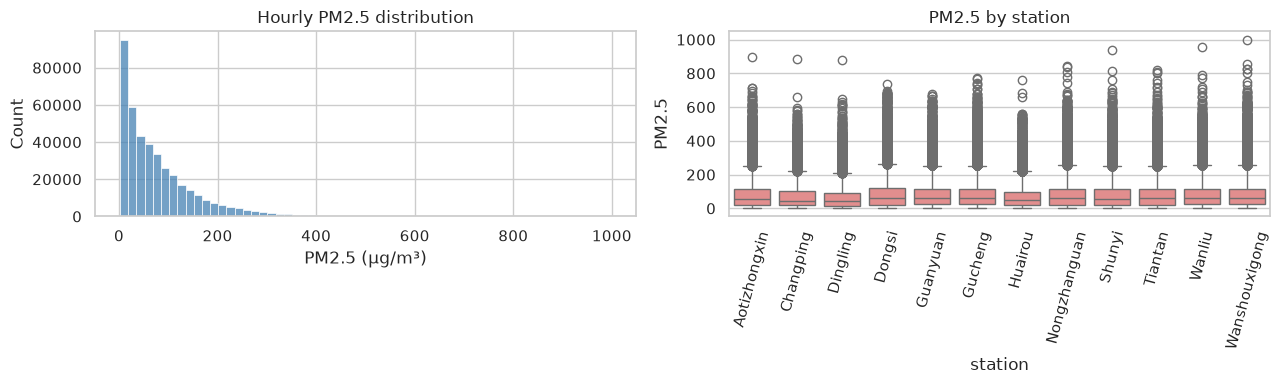

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data['PM2.5'].dropna(), bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Hourly PM2.5 distribution'); axes[0].set_xlabel('PM2.5 (µg/m³)')
sns.boxplot(data=data, x='station', y='PM2.5', ax=axes[1], color='lightcoral')
axes[1].set_title('PM2.5 by station'); axes[1].tick_params(axis='x', rotation=75)
plt.tight_layout()


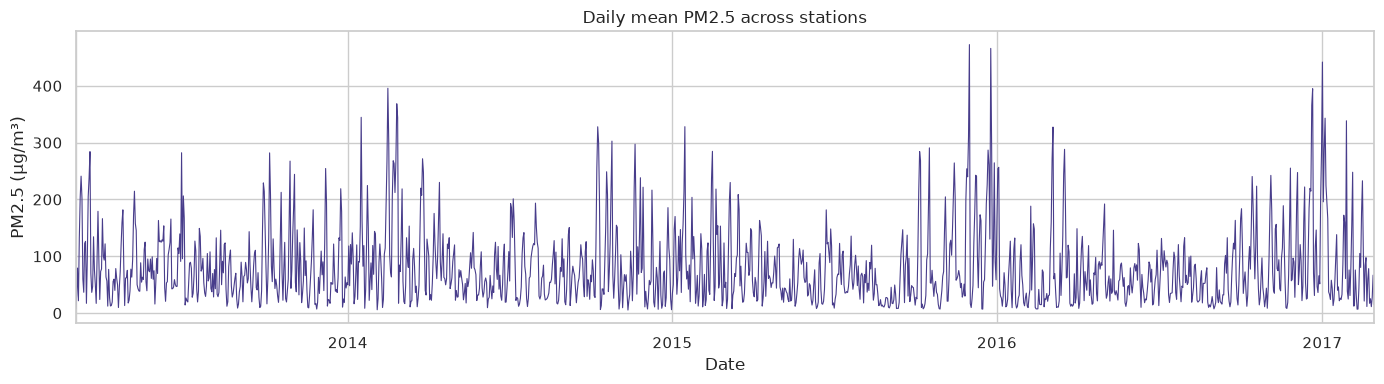

In [6]:
daily = data.set_index('datetime').groupby('station')['PM2.5'].resample('D').mean().reset_index()
network_daily = data.set_index('datetime')['PM2.5'].resample('D').mean()
plt.figure(figsize=(14,4)); network_daily.plot(color='darkslateblue', linewidth=0.8)
plt.title('Daily mean PM2.5 across stations'); plt.ylabel('PM2.5 (µg/m³)'); plt.xlabel('Date'); plt.tight_layout()


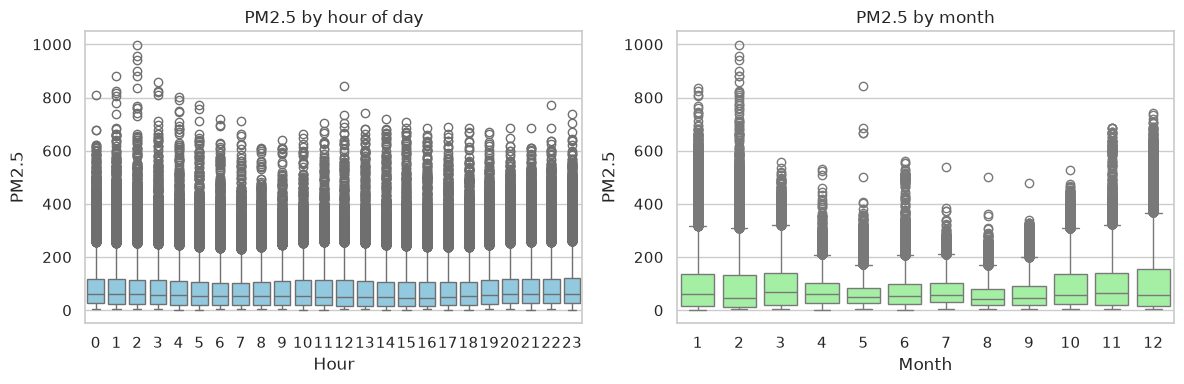

In [7]:
data['month_for_eda'] = data['datetime'].dt.month
data['hour_for_eda'] = data['datetime'].dt.hour
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=data, x='hour_for_eda', y='PM2.5', ax=axes[0], color='skyblue')
axes[0].set_title('PM2.5 by hour of day'); axes[0].set_xlabel('Hour')
sns.boxplot(data=data, x='month_for_eda', y='PM2.5', ax=axes[1], color='palegreen')
axes[1].set_title('PM2.5 by month'); axes[1].set_xlabel('Month')
plt.tight_layout()


**How to read the charts:** broad station differences point to local conditions, while repeated hourly or monthly patterns support calendar features. Daily network averages smooth individual noisy readings but are only an EDA view; the model remains an hourly station-level forecast.

### Outliers

We use the IQR rule as a flag, not an automatic deletion rule. For pollution measurements, the upper tail may represent genuine pollution episodes. We inspect the number flagged and retain valid peaks; the tree models can learn nonlinear response, and MAE alongside RMSE shows typical and large-error sensitivity.


In [8]:
for col in ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']:
    x = data[col].dropna()
    q1, q3 = x.quantile([.25,.75]); iqr = q3-q1
    count = ((x < q1-1.5*iqr) | (x > q3+1.5*iqr)).sum()
    print(f'{col:8s}: {count:6d} flagged ({count/len(x):.1%}); range {x.min():.1f} to {x.max():.1f}')


PM2.5   :  19142 flagged (4.6%); range 2.0 to 999.0
PM10    :  14658 flagged (3.5%); range 2.0 to 999.0
SO2     :  35566 flagged (8.6%); range 0.3 to 500.0
NO2     :   7021 flagged (1.7%); range 1.0 to 290.0
CO      :  28054 flagged (7.0%); range 100.0 to 10000.0
O3      :  16599 flagged (4.1%); range 0.2 to 1071.0
TEMP    :      0 flagged (0.0%); range -19.9 to 41.6
PRES    :      0 flagged (0.0%); range 982.4 to 1042.8
DEWP    :      0 flagged (0.0%); range -43.4 to 29.1
RAIN    :  16520 flagged (3.9%); range 0.0 to 72.5
WSPM    :  23079 flagged (5.5%); range 0.0 to 13.2


## 4. Prepare a one-hour-ahead forecasting table

Rows are sorted within station before lag creation. Features use current-hour measurements to forecast the following hour. We include PM2.5 lags at 1, 3, and 24 hours and a trailing 24-hour mean shifted to end at the current hour. The shift is essential: it ensures the rolling average never includes the target hour. Wind direction is encoded using sine/cosine so north-adjacent directions are also numerically adjacent. The response is next-hour PM2.5 (`target_next_hour`).

Rows with no target or missing required lag values are removed. Predictor imputation is fitted after the time split.


In [9]:
data = data.drop(columns=['month_for_eda','hour_for_eda'], errors='ignore')
data = data.sort_values(['station','datetime']).reset_index(drop=True)
# Wind direction is circular; map compass points to angle, unknown/calm values stay missing.
wind_angle = {'N':0,'NNE':22.5,'NE':45,'ENE':67.5,'E':90,'ESE':112.5,'SE':135,'SSE':157.5,'S':180,'SSW':202.5,'SW':225,'WSW':247.5,'W':270,'WNW':292.5,'NW':315,'NNW':337.5}
angle = data['wd'].map(wind_angle) * np.pi / 180
data['wind_sin'] = np.sin(angle)
data['wind_cos'] = np.cos(angle)
for lag in [1,3,24]:
    data[f'PM2.5_lag_{lag}'] = data.groupby('station')['PM2.5'].shift(lag)
data['PM2.5_mean_24h'] = data.groupby('station')['PM2.5'].transform(lambda s: s.shift(1).rolling(24, min_periods=12).mean())
data['target_next_hour'] = data.groupby('station')['PM2.5'].shift(-1)
# Time features refer to forecast hour, known at forecast time.
forecast_time = data['datetime'] + pd.Timedelta(hours=1)
data['hour_sin'] = np.sin(2*np.pi*forecast_time.dt.hour/24)
data['hour_cos'] = np.cos(2*np.pi*forecast_time.dt.hour/24)
data['dayofweek_sin'] = np.sin(2*np.pi*forecast_time.dt.dayofweek/7)
data['dayofweek_cos'] = np.cos(2*np.pi*forecast_time.dt.dayofweek/7)
data['month_sin'] = np.sin(2*np.pi*forecast_time.dt.month/12)
data['month_cos'] = np.cos(2*np.pi*forecast_time.dt.month/12)
model_data = data.dropna(subset=['target_next_hour','PM2.5_lag_1','PM2.5_lag_3','PM2.5_lag_24','PM2.5_mean_24h']).copy()
print('Model rows:', model_data.shape[0], '| time:', model_data.datetime.min(), 'to', model_data.datetime.max())


Model rows: 397772 | time: 2013-03-02 00:00:00 to 2017-02-28 22:00:00


## 5. Chronological train/test split and feature selection

The cutoff is defined on unique timestamps, not rows, so all station readings from an hour remain together. The first 80% of time is training and the final 20% is the untouched test period. This evaluates future-time generalization at stations represented in training. It does not claim generalization to a completely new station.

Current-hour pollutants (including PM10 and other pollutant readings) are allowed because the stated forecast is one hour ahead and they are available at forecast origin. If the real deployment cannot access them at that time, they should be removed and the experiment rerun.


In [10]:
timestamps = np.sort(model_data['datetime'].unique())
cutoff = timestamps[int(len(timestamps)*0.8)]
train = model_data[model_data['datetime'] < cutoff].copy()
test = model_data[model_data['datetime'] >= cutoff].copy()
feature_cols = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM',
                'wind_sin','wind_cos','PM2.5_lag_1','PM2.5_lag_3','PM2.5_lag_24','PM2.5_mean_24h',
                'hour_sin','hour_cos','dayofweek_sin','dayofweek_cos','month_sin','month_cos','station']
X_train = pd.get_dummies(train[feature_cols], columns=['station'], dtype=int)
X_test = pd.get_dummies(test[feature_cols], columns=['station'], dtype=int).reindex(columns=X_train.columns, fill_value=0)
y_train = train['target_next_hour']
y_test = test['target_next_hour']
print('Cutoff:', cutoff)
print('Train:', len(train), train.datetime.min(), 'to', train.datetime.max())
print('Test :', len(test), test.datetime.min(), 'to', test.datetime.max())
print('Features:', X_train.shape[1])


Cutoff: 2016-05-11T23:00:00.000000
Train: 318045 2013-03-02 00:00:00 to 2016-05-11 22:00:00
Test : 79727 2016-05-11 23:00:00 to 2017-02-28 22:00:00
Features: 35


### Impute predictors and scale linear models

Median imputation parameters are learned only from training predictors, then applied unchanged to test predictors. Median is robust to skew and occasional high pollution observations. Linear regression and Ridge are scaled because inputs have different units and scales. Tree models use imputed original-scale features and do not require standardization.


In [11]:
medians = X_train.median()
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Remaining missing train/test values:', X_train.isna().sum().sum(), X_test.isna().sum().sum())


Remaining missing train/test values: 0 0


## 6. Train and compare models

We compare a persistence baseline (next-hour value equals current-hour PM2.5), Linear Regression, Ridge, Random Forest, and XGBoost. The persistence baseline is important in time series: a complex model should beat the simple forecast that pollution stays near its latest observed level. Each model is fit once with documented parameters. RMSE is the selection metric; MAE gives an intuitive average absolute miss and R² gives variance explained relative to a constant-mean prediction.


In [12]:
def score_predictions(name, actual, predicted):
    return {'Model': name, 'RMSE': mean_squared_error(actual, predicted)**0.5,
            'MAE': mean_absolute_error(actual, predicted), 'R2': r2_score(actual, predicted)}

predictions = {}
# Persistence: one-hour ahead equals current PM2.5.
predictions['Persistence (lag 1)'] = test['PM2.5'].fillna(test['PM2.5_lag_1']).to_numpy()
linear = LinearRegression().fit(X_train_scaled, y_train)
predictions['Linear Regression'] = linear.predict(X_test_scaled)
ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)
predictions['Ridge (alpha=1)'] = ridge.predict(X_test_scaled)
rf = RandomForestRegressor(n_estimators=120, max_depth=18, min_samples_leaf=2,
                           random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
predictions['Random Forest'] = rf.predict(X_test)
xgb = XGBRegressor(n_estimators=180, max_depth=6, learning_rate=0.08,
                   subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror',
                   random_state=RANDOM_STATE, n_jobs=-1)
xgb.fit(X_train, y_train)
predictions['XGBoost'] = xgb.predict(X_test)
results = pd.DataFrame([score_predictions(name, y_test, pred) for name,pred in predictions.items()]).set_index('Model').sort_values('RMSE')
results


,RMSE,MAE,R2
Model,,,
Random Forest,18.019265,9.388363,0.953873
XGBoost,18.245728,9.506659,0.952706
Linear Regression,19.096410,10.152195,0.948194
Ridge (alpha=1),19.096467,10.152280,0.948193
Persistence (lag 1),19.684901,10.144079,0.944951


Selected by test RMSE: Random Forest


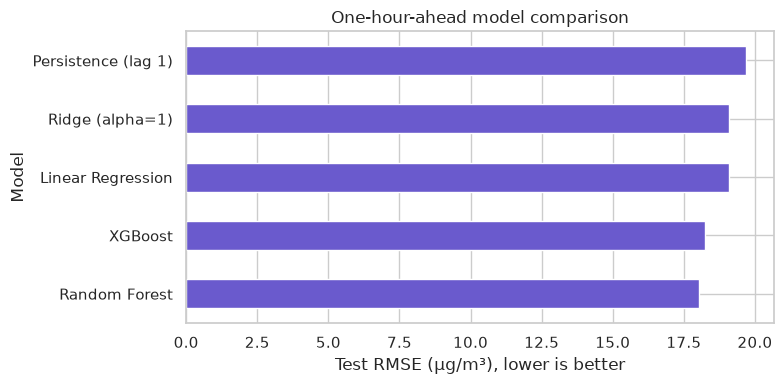

In [13]:
ax = results['RMSE'].sort_values().plot(kind='barh', figsize=(8,4), color='slateblue')
ax.set_xlabel('Test RMSE (µg/m³), lower is better'); ax.set_title('One-hour-ahead model comparison'); plt.tight_layout()
best_name = results.index[0]
best_pred = predictions[best_name]
print('Selected by test RMSE:', best_name)


## 7. Evaluate the selected model

The plot below compares predicted and actual values over a short continuous slice of the test period for one station. A short slice is easier to read than plotting every station and every hour at once. Residuals are prediction minus observed concentration; systematic patterns indicate missed structure.


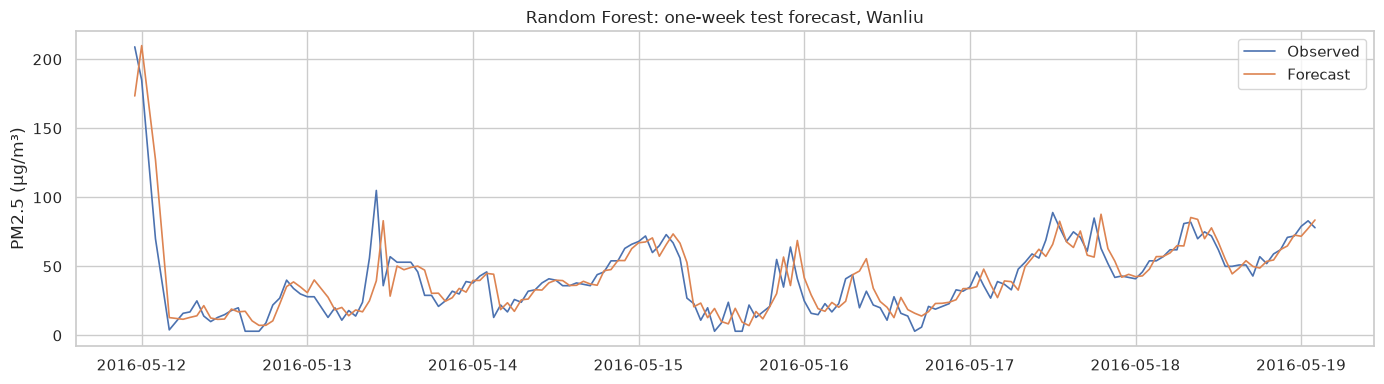

In [14]:
test_results = test[['datetime','station','target_next_hour']].copy()
test_results['prediction'] = best_pred
test_results['residual'] = test_results['prediction'] - test_results['target_next_hour']
example_station = test_results['station'].value_counts().index[0]
plot_data = test_results[test_results.station == example_station].sort_values('datetime').head(24*7)
plt.figure(figsize=(14,4))
plt.plot(plot_data.datetime, plot_data.target_next_hour, label='Observed', linewidth=1.2)
plt.plot(plot_data.datetime, plot_data.prediction, label='Forecast', linewidth=1.2)
plt.title(f'{best_name}: one-week test forecast, {example_station}')
plt.ylabel('PM2.5 (µg/m³)'); plt.legend(); plt.tight_layout()


RMSE    18.019265
MAE      9.388363
R2       0.953873
Name: Random Forest, dtype: float64


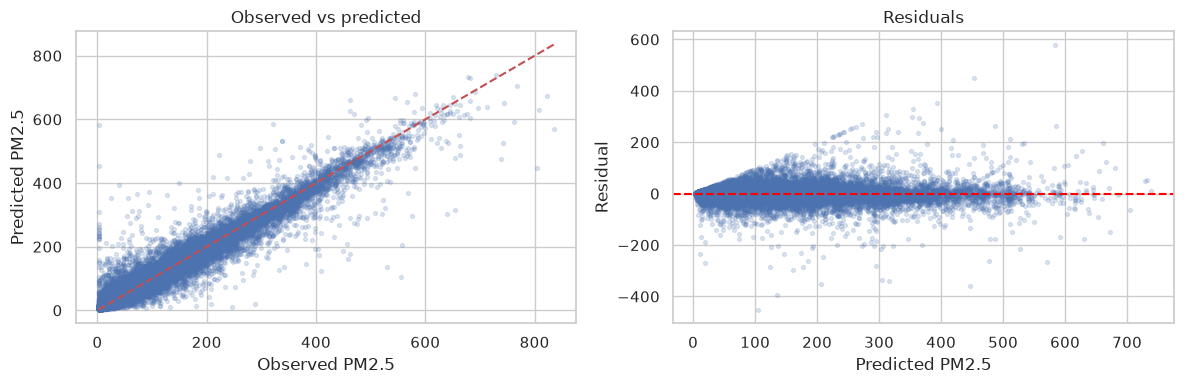

In [15]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].scatter(y_test, best_pred, alpha=.18, s=8)
lims=[min(y_test.min(),best_pred.min()),max(y_test.max(),best_pred.max())]
axes[0].plot(lims,lims,'r--'); axes[0].set(xlabel='Observed PM2.5',ylabel='Predicted PM2.5',title='Observed vs predicted')
axes[1].scatter(best_pred, test_results['residual'], alpha=.18, s=8)
axes[1].axhline(0,color='red',linestyle='--'); axes[1].set(xlabel='Predicted PM2.5',ylabel='Residual',title='Residuals')
plt.tight_layout()
print(results.loc[best_name])


## 8. Error analysis and interpretation

Forecast errors are grouped by observed pollution range and station. These summaries show whether the model is less reliable during high-pollution episodes or at particular monitoring locations. Counts matter: very high-concentration rows are usually less common, so their estimated average error is less stable.


In [16]:
err = test_results.copy()
err['abs_error'] = err.residual.abs()
err['pollution_band'] = pd.cut(err.target_next_hour, bins=[-0.01,35,75,150, np.inf],
                               labels=['0–35','35–75','75–150','>150'])
print('Error by observed PM2.5 range:')
display(err.groupby('pollution_band', observed=True).agg(n=('abs_error','size'), MAE=('abs_error','mean'), bias=('residual','mean')))
print('Stations with largest test MAE:')
display(err.groupby('station').agg(n=('abs_error','size'), MAE=('abs_error','mean')).sort_values('MAE',ascending=False))


Error by observed PM2.5 range:


,n,MAE,bias
pollution_band,,,
0–35,30767,5.193236,2.624648
35–75,19239,8.236957,1.789897
75–150,18325,11.063438,-0.973862
>150,11396,19.964670,-6.460228


Stations with largest test MAE:


,n,MAE
station,,
Wanshouxigong,6617,10.451473
Dongsi,6372,10.217449
Guanyuan,6629,9.988939
Tiantan,6735,9.866505
Gucheng,6668,9.718595
Nongzhanguan,6698,9.559306
Aotizhongxin,6708,9.485383
Shunyi,6505,9.230964
Changping,6748,9.210966


## 9. Feature importance and limitations

Permutation importance shuffles one test feature at a time and measures the resulting R² decrease. It describes predictive usefulness in this test sample, not causation. Correlated pollutants can substitute for one another, so their individual permutation importance may be shared or understated.

The model forecasts one hour ahead using synchronous pollutant/weather readings and station identity. It does not forecast multiple days ahead or transfer to an unseen station. Missing-value imputation is intentionally simple and training-based. A next step would compare expanding-window validation and longer horizons, then tune the model using time-aware validation; the held-out final period should remain untouched until final evaluation.


In [17]:
model_by_name = {'Linear Regression': linear, 'Ridge (alpha=1)': ridge,
                 'Random Forest': rf, 'XGBoost': xgb}
if best_name in model_by_name:
    fitted = model_by_name[best_name]
    if best_name in ['Random Forest','XGBoost']:
        importance = pd.Series(fitted.feature_importances_, index=X_train.columns)
    else:
        # For scaled linear models use absolute standardized coefficient magnitude.
        importance = pd.Series(np.abs(fitted.coef_), index=X_train.columns)
    print('Top predictive features (importance, not causal effects):')
    display(importance.sort_values(ascending=False).head(15))


Top predictive features (importance, not causal effects):


PM2.5             0.957736
PM2.5_lag_1       0.008817
WSPM              0.004394
PM10              0.003553
PM2.5_mean_24h    0.002551
PM2.5_lag_3       0.002304
NO2               0.002161
DEWP              0.002088
PM2.5_lag_24      0.001624
TEMP              0.001574
SO2               0.001522
CO                0.001492
PRES              0.001478
wind_cos          0.001297
O3                0.001213
dtype: float64

## 10. Conclusion

This notebook uses OpenML dataset 42933 and frames the assignment as a station-level, one-hour-ahead PM2.5 forecasting problem. Model choice is based on chronological test RMSE and is interpreted alongside MAE, R², plots, and pollution-band errors. Record the printed metric table and selected model in the written submission after running the notebook in your environment. State clearly that this is a one-hour horizon and that the final time block is the test set.

**Sources:** OpenML, [Beijing Multi-Site Air Quality dataset 42933](https://www.openml.org/d/42933), original dataset citation: Zhang et al. (2017), “Cautionary Tales on Air-Quality Improvement in Beijing,” *Proceedings of the Royal Society A*, 473(2205), 20170457. The instructions define the assignment scope; the dataset and one-hour forecast framing inform this notebook. Cite any additional code or assistance required by your course policy.
